# Pipeline Stacking + Optuna (ColumnTransformer + Pipeline)

- **ColumnTransformer** : CpG (MICE + Scaler) | Sexe (passthrough)
- **StackingRegressor** optimise par Optuna (params deja obtenus)
- **5-Fold CV** sans data leakage (selection + imputation intra-fold)

In [6]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
from time import time

from sklearn.linear_model import ElasticNet, Ridge, BayesianRidge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from scipy import stats
from scipy.interpolate import griddata

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D

SEED = 42
np.random.seed(SEED)
DATA_DIR = Path('Data')
TOP_K = 500
N_FOLDS = 5

print('Imports OK')

Imports OK


## 1. Chargement des donnees brutes

In [7]:
ind = pd.read_csv(DATA_DIR / 'annot_projet.csv')
ind = ind.dropna(subset=['age', 'Sample_description']).copy()
ind['Sample_description'] = ind['Sample_description'].astype(str)
ind = ind.set_index('Sample_description')

data_path = DATA_DIR / 'c_sample.csv'
sample_header = pd.read_csv(data_path, nrows=0)
common_ids = [s for s in sample_header.columns if s in ind.index]

y = ind.loc[common_ids, 'age'].values.astype(np.float32)

sex = ind.loc[common_ids, 'female'].apply(
    lambda x: 1.0 if str(x).lower() == 'true' else (0.0 if str(x).lower() == 'false' else np.nan)
).values.astype(np.float32)
sex = np.where(np.isnan(sex), np.nanmean(sex), sex)

print(f'Chargement CpG bruts...')
t0 = time()
rows = []
for chunk in pd.read_csv(data_path, usecols=common_ids, chunksize=5000):
    rows.append(chunk.to_numpy(dtype=np.float32))
X_all = np.vstack(rows).T
print(f'{len(common_ids)} echantillons, {X_all.shape[1]} CpG, NaN={np.isnan(X_all).mean()*100:.2f}% ({time()-t0:.1f}s)')

Chargement CpG bruts...
400 echantillons, 894006 CpG, NaN=2.67% (29.4s)


## 2. Params Optuna deja optimises

In [8]:
# Params optimises par Optuna (resultats precedents)
OPTUNA_PARAMS_PER_FOLD = [
    {'enet_alpha': 0.1111, 'enet_l1': 0.2434, 'ridge_alpha': 0.1497, 'svr_C': 17.7405,
     'knn_n': 4, 'rf_n': 300, 'rf_depth': 10, 'xgb_n': 300, 'xgb_depth': 4,
     'xgb_lr': 0.0431, 'lgbm_n': 400, 'lgbm_depth': 8, 'lgbm_lr': 0.2142,
     'meta_alpha': 25.544, 'passthrough': True},
    {'enet_alpha': 1.9335, 'enet_l1': 0.3999, 'ridge_alpha': 0.3903, 'svr_C': 3.1735,
     'knn_n': 11, 'rf_n': 150, 'rf_depth': 8, 'xgb_n': 200, 'xgb_depth': 7,
     'xgb_lr': 0.0771, 'lgbm_n': 150, 'lgbm_depth': 6, 'lgbm_lr': 0.0502,
     'meta_alpha': 99.6794, 'passthrough': True},
    {'enet_alpha': 0.08, 'enet_l1': 0.3692, 'ridge_alpha': 0.0024, 'svr_C': 25.2494,
     'knn_n': 19, 'rf_n': 150, 'rf_depth': 4, 'xgb_n': 550, 'xgb_depth': 7,
     'xgb_lr': 0.1974, 'lgbm_n': 500, 'lgbm_depth': 7, 'lgbm_lr': 0.2066,
     'meta_alpha': 0.7164, 'passthrough': False},
    {'enet_alpha': 0.029, 'enet_l1': 0.6232, 'ridge_alpha': 15.2078, 'svr_C': 7.5337,
     'knn_n': 17, 'rf_n': 200, 'rf_depth': 9, 'xgb_n': 500, 'xgb_depth': 8,
     'xgb_lr': 0.1499, 'lgbm_n': 350, 'lgbm_depth': 4, 'lgbm_lr': 0.0341,
     'meta_alpha': 0.8066, 'passthrough': False},
    {'enet_alpha': 1.0387, 'enet_l1': 0.7379, 'ridge_alpha': 0.0025, 'svr_C': 4.6404,
     'knn_n': 8, 'rf_n': 300, 'rf_depth': 5, 'xgb_n': 250, 'xgb_depth': 4,
     'xgb_lr': 0.1908, 'lgbm_n': 200, 'lgbm_depth': 9, 'lgbm_lr': 0.0311,
     'meta_alpha': 98.9044, 'passthrough': True},
]

print(f'{len(OPTUNA_PARAMS_PER_FOLD)} jeux de params charges (1 par fold)')

5 jeux de params charges (1 par fold)


## 3. Fonctions : selection, preprocessing, stacking

In [9]:
def select_top_k(X_train, y_train, k):
    """Top-k CpG par correlation absolue (NaN-safe, train only)."""
    y_c = y_train - y_train.mean()
    y_den = np.sqrt(np.sum(y_c ** 2))
    col_means = np.nanmean(X_train, axis=0, keepdims=True)
    X_filled = np.where(np.isnan(X_train), col_means, X_train)
    x_c = X_filled - X_filled.mean(axis=0, keepdims=True)
    num = x_c.T @ y_c
    den = np.sqrt(np.sum(x_c ** 2, axis=0)) * y_den
    corrs = np.abs(np.divide(num, den, out=np.zeros_like(num), where=den != 0))
    return np.argsort(corrs)[::-1][:k]


def build_preprocessing():
    """ColumnTransformer : CpG -> MICE + Scaler, Sexe -> passthrough."""
    cpg_pipe = Pipeline([
        ('imputer', IterativeImputer(
            estimator=BayesianRidge(), n_nearest_features=100,
            max_iter=10, random_state=SEED)),
        ('scaler', StandardScaler()),
    ])
    return ColumnTransformer([
        ('cpg', cpg_pipe, list(range(TOP_K))),
        ('sex', 'passthrough', [TOP_K]),
    ])


def build_stacking(p):
    """StackingRegressor avec params Optuna."""
    estimators = [
        ('enet', ElasticNet(alpha=p['enet_alpha'], l1_ratio=p['enet_l1'], max_iter=10000, random_state=SEED)),
        ('ridge', Ridge(alpha=p['ridge_alpha'], random_state=SEED)),
        ('svr', SVR(C=p['svr_C'], kernel='rbf')),
        ('knn', KNeighborsRegressor(n_neighbors=p['knn_n'], weights='distance')),
        ('rf', RandomForestRegressor(n_estimators=p['rf_n'], max_depth=p['rf_depth'], random_state=SEED, n_jobs=-1)),
        ('xgb', XGBRegressor(n_estimators=p['xgb_n'], max_depth=p['xgb_depth'], learning_rate=p['xgb_lr'],
                             subsample=0.8, colsample_bytree=0.8, random_state=SEED, n_jobs=-1, verbosity=0)),
        ('lgbm', LGBMRegressor(n_estimators=p['lgbm_n'], max_depth=p['lgbm_depth'], learning_rate=p['lgbm_lr'],
                               subsample=0.8, colsample_bytree=0.8, random_state=SEED, n_jobs=-1, verbose=-1)),
    ]
    return StackingRegressor(
        estimators=estimators,
        final_estimator=Ridge(alpha=p['meta_alpha'], random_state=SEED),
        cv=3, passthrough=p.get('passthrough', True), n_jobs=-1
    )


print('Fonctions definies.')

Fonctions definies.


## 4. 5-Fold CV (sans data leakage)

In [10]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_results = []
all_y_true, all_y_pred = [], []

print(f'Pipeline : ColumnTransformer + Stacking (params Optuna pre-optimises)')
print(f'{X_all.shape[1]} CpG -> Top-{TOP_K} (corr intra-fold) + sexe')
print('=' * 60)

for fold_i, (train_idx, test_idx) in enumerate(kf.split(y)):
    t_fold = time()
    params = OPTUNA_PARAMS_PER_FOLD[fold_i]
    y_train, y_test = y[train_idx], y[test_idx]

    # 1. Selection top-K (train only)
    top_idx = select_top_k(X_all[train_idx], y_train, TOP_K)
    X_tr = np.column_stack([X_all[train_idx][:, top_idx], sex[train_idx]])
    X_te = np.column_stack([X_all[test_idx][:, top_idx], sex[test_idx]])

    # 2. ColumnTransformer (fit train, transform test)
    ct = build_preprocessing()
    X_tr = ct.fit_transform(X_tr)
    X_te = ct.transform(X_te)

    # 3. Stacking (params Optuna du fold)
    stacking = build_stacking(params)
    stacking.fit(X_tr, y_train)
    y_pred = stacking.predict(X_te)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    fold_results.append({'fold': fold_i+1, 'mae': mae, 'r2': r2})
    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())

    print(f'Fold {fold_i+1}/{N_FOLDS} : MAE={mae:.3f}, R2={r2:.3f} ({time()-t_fold:.1f}s)')

df_res = pd.DataFrame(fold_results)
t_crit = stats.t.ppf(0.975, df=N_FOLDS-1)
mae_mean = df_res['mae'].mean()
mae_ci = t_crit * df_res['mae'].std(ddof=1) / np.sqrt(N_FOLDS)
r2_mean = df_res['r2'].mean()
r2_ci = t_crit * df_res['r2'].std(ddof=1) / np.sqrt(N_FOLDS)

print('=' * 60)
print(f'MAE = {mae_mean:.3f} +/- {mae_ci:.3f} (IC 95%)')
print(f'R2  = {r2_mean:.3f} +/- {r2_ci:.3f} (IC 95%)')

Pipeline : ColumnTransformer + Stacking (params Optuna pre-optimises)
894006 CpG -> Top-500 (corr intra-fold) + sexe
Fold 1/5 : MAE=2.887, R2=0.968 (211.6s)
Fold 2/5 : MAE=3.367, R2=0.958 (124.8s)
Fold 3/5 : MAE=3.504, R2=0.899 (150.0s)
Fold 4/5 : MAE=3.424, R2=0.894 (4.8s)
Fold 5/5 : MAE=3.425, R2=0.921 (80.8s)
MAE = 3.321 +/- 0.308 (IC 95%)
R2  = 0.928 +/- 0.042 (IC 95%)


## 5. Visualisation 3D (Optuna landscape) + MAE par fold

In [11]:
# --- Recreer un study Optuna pour la visualisation 3D ---
# On simule l'exploration autour des params optimaux
# pour visualiser le paysage d'optimisation

# Utiliser les params du meilleur fold comme centre
best_fold_idx = df_res['mae'].idxmin()
center_params = OPTUNA_PARAMS_PER_FOLD[best_fold_idx]

# Preparer les donnees du meilleur fold pour l'exploration
kf2 = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
for i, (train_idx, test_idx) in enumerate(kf2.split(y)):
    if i == best_fold_idx:
        top_idx = select_top_k(X_all[train_idx], y[train_idx], TOP_K)
        X_tr_viz = np.column_stack([X_all[train_idx][:, top_idx], sex[train_idx]])
        ct_viz = build_preprocessing()
        X_tr_viz = ct_viz.fit_transform(X_tr_viz)
        y_tr_viz = y[train_idx]
        break

print(f'Exploration du paysage sur fold {best_fold_idx+1} (train shape={X_tr_viz.shape})')

# Optuna study : exploration autour du point optimal
def make_objective(X_data, y_data):
    def objective(trial):
        p = {
            'enet_alpha': trial.suggest_float('enet_alpha', 0.005, 2.0, log=True),
            'enet_l1': trial.suggest_float('enet_l1', 0.1, 0.9),
            'ridge_alpha': trial.suggest_float('ridge_alpha', 0.001, 50.0, log=True),
            'svr_C': trial.suggest_float('svr_C', 0.5, 50.0, log=True),
            'knn_n': trial.suggest_int('knn_n', 3, 20),
            'rf_n': trial.suggest_int('rf_n', 100, 400, step=50),
            'rf_depth': trial.suggest_int('rf_depth', 4, 15),
            'xgb_n': trial.suggest_int('xgb_n', 100, 500, step=50),
            'xgb_depth': trial.suggest_int('xgb_depth', 3, 8),
            'xgb_lr': trial.suggest_float('xgb_lr', 0.01, 0.3, log=True),
            'lgbm_n': trial.suggest_int('lgbm_n', 100, 500, step=50),
            'lgbm_depth': trial.suggest_int('lgbm_depth', 3, 10),
            'lgbm_lr': trial.suggest_float('lgbm_lr', 0.01, 0.3, log=True),
            'meta_alpha': trial.suggest_float('meta_alpha', 0.1, 100.0, log=True),
            'passthrough': trial.suggest_categorical('passthrough', [True, False]),
        }
        stk = build_stacking(p)
        cv_inner = KFold(n_splits=3, shuffle=True, random_state=SEED)
        maes = []
        for tr, te in cv_inner.split(y_data):
            stk_clone = build_stacking(p)
            stk_clone.fit(X_data[tr], y_data[tr])
            maes.append(mean_absolute_error(y_data[te], stk_clone.predict(X_data[te])))
        return np.mean(maes)
    return objective

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(make_objective(X_tr_viz, y_tr_viz), n_trials=40, show_progress_bar=True)
print(f'Best trial MAE: {study.best_value:.3f}')

Exploration du paysage sur fold 1 (train shape=(320, 439))


  0%|          | 0/40 [00:00<?, ?it/s]

Best trial MAE: 3.470


Top 2 params: passthrough, enet_alpha


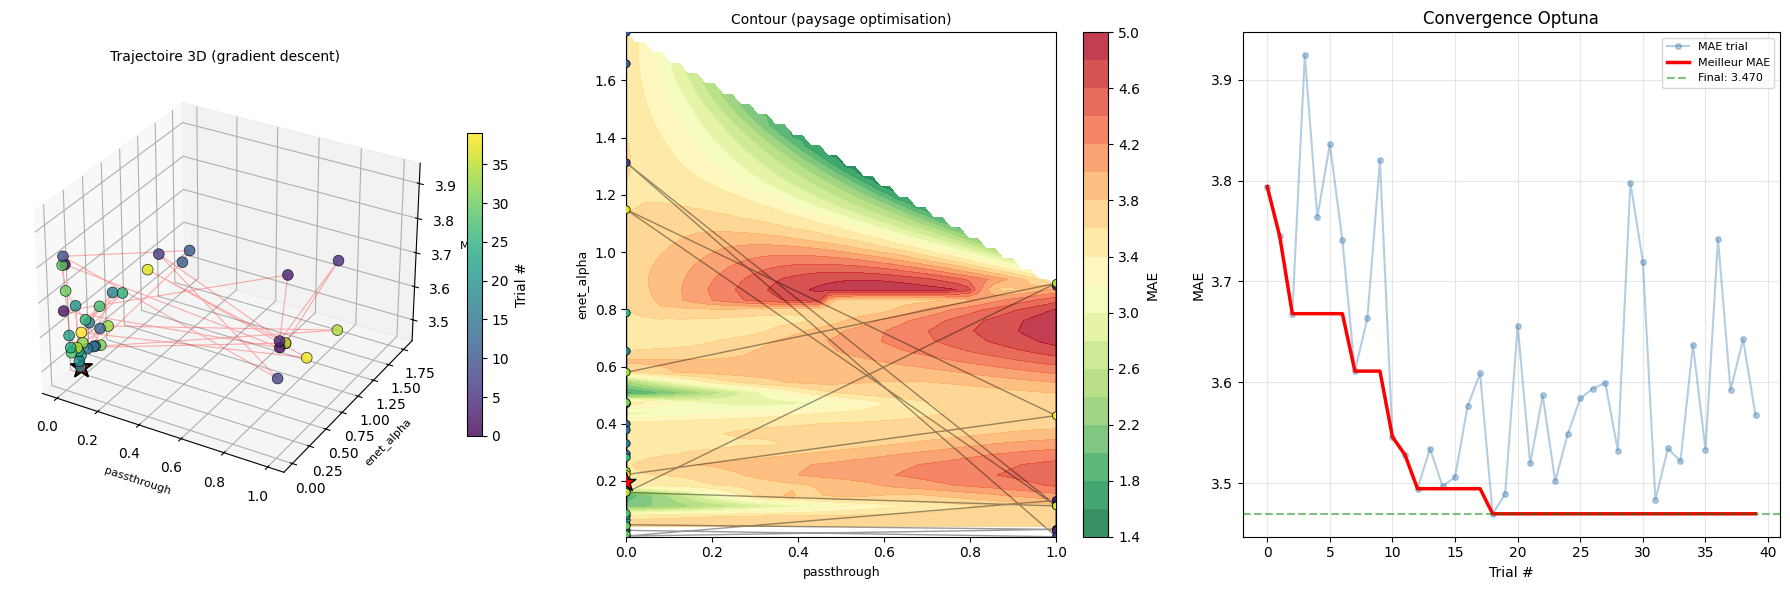

In [12]:
# --- Extraire donnees des trials ---
importances = optuna.importance.get_param_importances(study)
p1, p2 = list(importances.keys())[:2]
print(f'Top 2 params: {p1}, {p2}')

trials_data = [{'trial': t.number, 'value': t.value,
                p1: t.params[p1], p2: t.params[p2]}
               for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
df_t = pd.DataFrame(trials_data)

x = df_t[p1].values
yv = df_t[p2].values
z = df_t['value'].values
tn = df_t['trial'].values
bi = np.argmin(z)

# === FIGURE 3D ===
fig = plt.figure(figsize=(18, 6))

# 1) 3D scatter + trajectoire
ax1 = fig.add_subplot(131, projection='3d')
sc = ax1.scatter(x, yv, z, c=tn, cmap='viridis', s=60, alpha=0.8, edgecolors='k', linewidth=0.5)
ax1.plot(x, yv, z, 'r-', alpha=0.3, linewidth=0.8)
ax1.scatter([x[bi]], [yv[bi]], [z[bi]], c='red', s=250, marker='*', edgecolors='k', linewidth=1.5, zorder=10)
ax1.set_xlabel(p1, fontsize=8)
ax1.set_ylabel(p2, fontsize=8)
ax1.set_zlabel('MAE', fontsize=8)
ax1.set_title('Trajectoire 3D (gradient descent)', fontsize=10)
fig.colorbar(sc, ax=ax1, label='Trial #', shrink=0.6)

# 2) Contour
ax2 = fig.add_subplot(132)
xi = np.linspace(x.min(), x.max(), 50)
yi = np.linspace(yv.min(), yv.max(), 50)
Xi, Yi = np.meshgrid(xi, yi)
Zi = griddata((x, yv), z, (Xi, Yi), method='cubic')
ct_plot = ax2.contourf(Xi, Yi, Zi, levels=20, cmap='RdYlGn_r', alpha=0.8)
fig.colorbar(ct_plot, ax=ax2, label='MAE')
ax2.plot(x, yv, 'k-', alpha=0.4, linewidth=1)
ax2.scatter(x, yv, c=tn, cmap='viridis', s=30, edgecolors='k', linewidth=0.5, zorder=5)
ax2.scatter(x[bi], yv[bi], c='red', s=200, marker='*', edgecolors='k', zorder=10)
ax2.set_xlabel(p1, fontsize=9)
ax2.set_ylabel(p2, fontsize=9)
ax2.set_title('Contour (paysage optimisation)', fontsize=10)

# 3) Convergence
ax3 = fig.add_subplot(133)
best_so_far = np.minimum.accumulate(z)
ax3.plot(tn, z, 'o-', alpha=0.4, markersize=4, color='steelblue', label='MAE trial')
ax3.plot(tn, best_so_far, 'r-', linewidth=2.5, label='Meilleur MAE')
ax3.axhline(y=best_so_far[-1], color='green', linestyle='--', alpha=0.5, label=f'Final: {best_so_far[-1]:.3f}')
ax3.set_xlabel('Trial #')
ax3.set_ylabel('MAE')
ax3.set_title('Convergence Optuna')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/pipeline_optuna_3d_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Predictions + MAE par fold

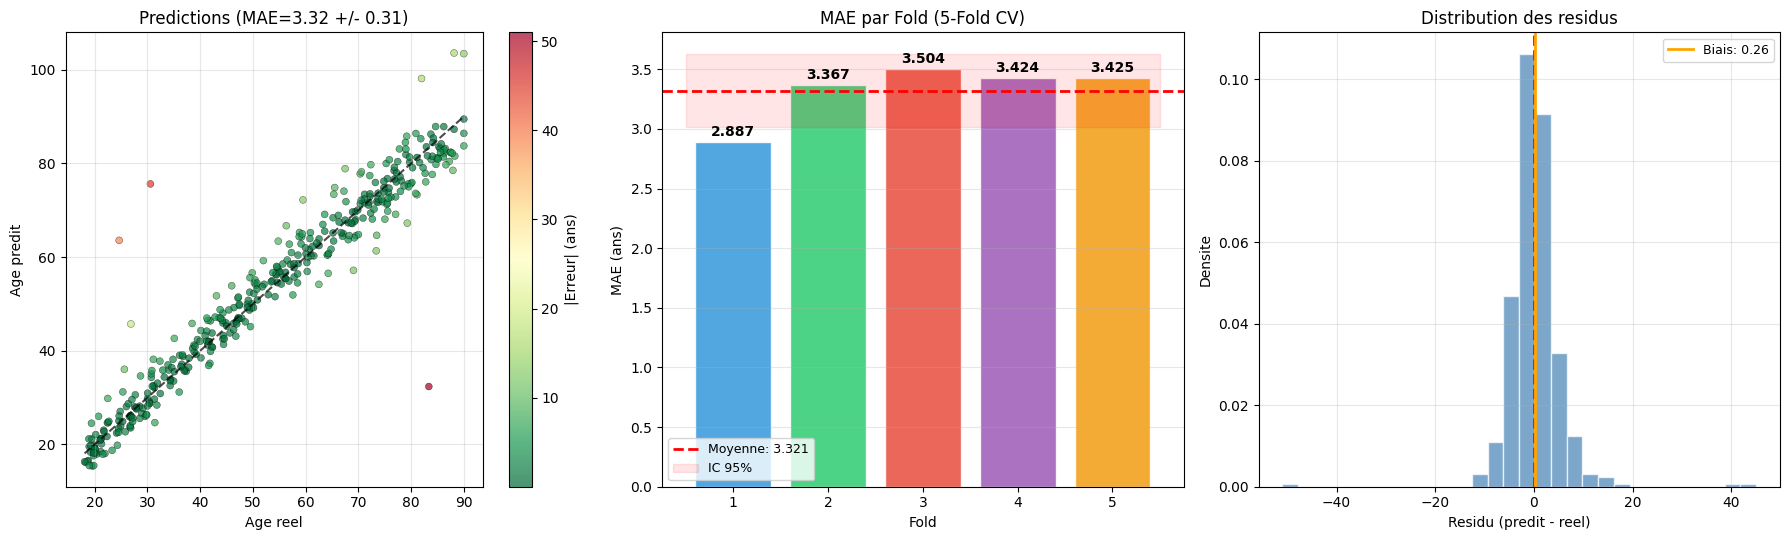

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
yt = np.array(all_y_true)
yp = np.array(all_y_pred)
res = yp - yt

# Predictions vs reel
ax = axes[0]
sc = ax.scatter(yt, yp, c=np.abs(res), cmap='RdYlGn_r', s=25, alpha=0.7, edgecolors='k', linewidth=0.3)
ax.plot([yt.min(), yt.max()], [yt.min(), yt.max()], 'k--', lw=1.5, alpha=0.7)
fig.colorbar(sc, ax=ax, label='|Erreur| (ans)')
ax.set_xlabel('Age reel')
ax.set_ylabel('Age predit')
ax.set_title(f'Predictions (MAE={mae_mean:.2f} +/- {mae_ci:.2f})')
ax.grid(True, alpha=0.3)

# MAE par fold
ax = axes[1]
colors_bar = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']
bars = ax.bar(df_res['fold'], df_res['mae'], color=colors_bar, alpha=0.85, edgecolor='white')
ax.axhline(y=mae_mean, color='red', linestyle='--', lw=2, label=f'Moyenne: {mae_mean:.3f}')
ax.fill_between([0.5, N_FOLDS+0.5], mae_mean-mae_ci, mae_mean+mae_ci, color='red', alpha=0.1, label=f'IC 95%')
for bar, m in zip(bars, df_res['mae']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, f'{m:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Fold')
ax.set_ylabel('MAE (ans)')
ax.set_title('MAE par Fold (5-Fold CV)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Residus
ax = axes[2]
ax.hist(res, bins=30, color='steelblue', alpha=0.7, edgecolor='white', density=True)
ax.axvline(x=0, color='red', linestyle='--', lw=2)
ax.axvline(x=res.mean(), color='orange', lw=2, label=f'Biais: {res.mean():.2f}')
ax.set_xlabel('Residu (predit - reel)')
ax.set_ylabel('Densite')
ax.set_title('Distribution des residus')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/pipeline_stacking_optuna_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Resume

In [14]:
print('=' * 60)
print('  PIPELINE : ColumnTransformer + Stacking + Optuna')
print('=' * 60)
print(f'  CpG         : {X_all.shape[1]} -> Top-{TOP_K} (corr intra-fold)')
print(f'  Preprocess  : MICE (BayesianRidge) + StandardScaler')
print(f'  Stacking    : ElasticNet, Ridge, SVR, KNN, RF, XGB, LGBM')
print(f'  Meta        : Ridge (passthrough selon fold)')
print(f'  MAE = {mae_mean:.3f} +/- {mae_ci:.3f} (IC 95%)')
print(f'  R2  = {r2_mean:.3f} +/- {r2_ci:.3f} (IC 95%)')
print('=' * 60)
print()
print('Architecture Pipeline sklearn :')
print(Pipeline([
    ('preprocess', build_preprocessing()),
    ('stacking', build_stacking(OPTUNA_PARAMS_PER_FOLD[0])),
]))

  PIPELINE : ColumnTransformer + Stacking + Optuna
  CpG         : 894006 -> Top-500 (corr intra-fold)
  Preprocess  : MICE (BayesianRidge) + StandardScaler
  Stacking    : ElasticNet, Ridge, SVR, KNN, RF, XGB, LGBM
  Meta        : Ridge (passthrough selon fold)
  MAE = 3.321 +/- 0.308 (IC 95%)
  R2  = 0.928 +/- 0.042 (IC 95%)

Architecture Pipeline sklearn :
Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cpg',
                                                  Pipeline(steps=[('imputer',
                                                                   IterativeImputer(estimator=BayesianRidge(),
                                                                                    n_nearest_features=100,
                                                                                    random_state=42)),
                                                                  ('scaler',
                                                                   Standa